In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [6]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 53)


In [7]:
df_map = df_map.copy()

df_map = df_map.drop_duplicates(subset=["id", "pesid"])

In [8]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return (
        df["br"]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.replace("BR-", "", regex=False)
        .str.strip()
    )

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

df_filtrado = df_map.copy()

if br_escolhida.strip() != "":
    df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_filtrado.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_filtrado[col] = pd.to_numeric(
        df_filtrado[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# =============================
# KM BIN
# =============================

df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# =============================
# Índice de severidade (AGORA FILTRADO)
# =============================

df_filtrado["severity_index"] = (
    4 * df_filtrado["Sum_Mortos"] +
    2 * df_filtrado["Sum_Feridos_Graves"] +
    1 * df_filtrado["Sum_Feridos_Leves"]
)

# =============================
# Agrupamento (AGORA FILTRADO)
# =============================

df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()
# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]
carros_leves = ["Automóvel"]
caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]
motos = ["Motocicleta", "Motoneta"]
ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# NOVO 🚍
onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# NOVO 🚍
layer_onibus = MarkerCluster(name="🚌 Ônibus").add_to(m)

# =============================
# Agrupamento auxiliar
# =============================

segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# =============================
# Plotagem
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Flags de veículos
    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()
    tem_onibus = grupo["tipo_veiculo"].isin(onibus).any()  # NOVO

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # Geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # Camadas específicas
    if tem_caminhao:
        folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

    if tem_carro:
        folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

    if tem_caminhonete:
        folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

    if tem_moto:
        folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

    if tem_ciclomotor:
        folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

    # NOVO 🚍
    if tem_onibus:
        folium.CircleMarker(
            [lat, lon],
            radius=radius,
            color="pink",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_onibus)

# =============================
# Controle
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar
# =============================

path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"

m.save(path)

print(f"Mapa gerado com sucesso em: {path}")

<>:210: SyntaxWarning: invalid escape sequence '\E'
<>:210: SyntaxWarning: invalid escape sequence '\E'
C:\Users\fause\AppData\Local\Temp\ipykernel_24760\1520945810.py:210: SyntaxWarning: invalid escape sequence '\E'
  path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"


Mostrando todas as rodovias
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html


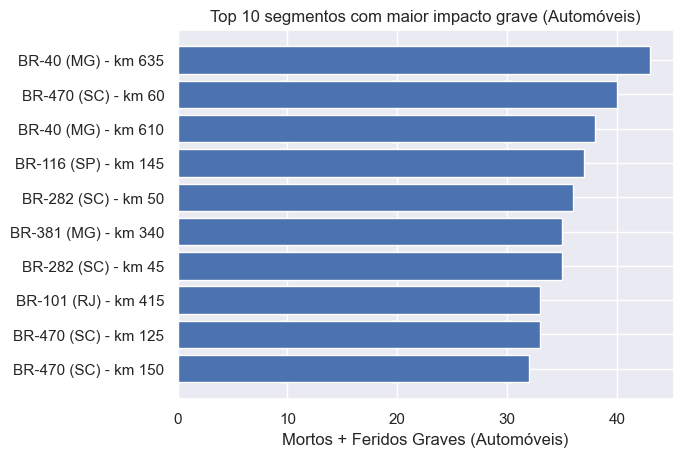

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos leves
# =============================

carros_leves = ["Automóvel"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_carro = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(carros_leves)
].copy()

# Remover possíveis inconsistências
df_carro = df_carro.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_carro["severity_index"] = (
    4 * df_carro["Sum_Mortos"] +
    2 * df_carro["Sum_Feridos_Graves"] +
    1 * df_carro["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_carro = df_carro.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_carro["segmento"] = (
    "BR-" + df_segmento_carro["br"].astype(str) + " (" +
    df_segmento_carro["uf"] + ") - km " +
    df_segmento_carro["km_bin"].astype(str)
)


# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_carro["impacto_grave"] = (
    df_segmento_carro["total_mortos"] +
    df_segmento_carro["total_feridos_graves"]
)

top10_impacto_carro = df_segmento_carro.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_carro["segmento"],
    top10_impacto_carro["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Automóveis)")
plt.title("Top 10 segmentos com maior impacto grave (Automóveis)")
plt.gca().invert_yaxis()

plt.show()


In [10]:
def consulta_por_variavel(df_original, df_top10, coluna_consulta):
    """
    df_original: df_caminhao (ou df_filtrado já tratado)
    df_top10: top10_impacto_caminhao
    coluna_consulta: string (ex: 'Fabricante', 'tipo_acidente')
    """

    # =============================
    # 1️⃣ Filtrar apenas segmentos do Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar dinamicamente
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin", coluna_consulta]
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar nome do segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar resultados
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [11]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "Fabricante"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Fabricante", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
   Fabricante  quantidade
         FIAT          37
   VOLKSWAGEN          33
    CHEVROLET          30
      HYUNDAI          15
      RENAULT          14
         FORD          10
        HONDA           9
       TOYOTA           8
      PEUGEOT           4
       NISSAN           3
Não Informado           2
      CITROEN           1
          KIA           1
MERCEDES-BENZ           1

===== BR-116 (SP) - km 145 =====
   Fabricante  quantidade
    CHEVROLET         193
   VOLKSWAGEN          88
         FIAT          78
      RENAULT          49
         FORD          47
Não Informado          37
        HONDA          32
      HYUNDAI          30
      PEUGEOT          22
       NISSAN          15
      CITROEN          14
       TOYOTA          12
          IMP           4
          BYD           3
          JAC           3
          KIA           3
        CHERY           2
MERCEDES-BENZ           2
         AUDI           1
        GEELY         

In [12]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "tipo_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_veiculo", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
tipo_veiculo  quantidade
   Automóvel         168

===== BR-116 (SP) - km 145 =====
tipo_veiculo  quantidade
   Automóvel         636

===== BR-282 (SC) - km 45 =====
tipo_veiculo  quantidade
   Automóvel          91

===== BR-282 (SC) - km 50 =====
tipo_veiculo  quantidade
   Automóvel          95

===== BR-381 (MG) - km 340 =====
tipo_veiculo  quantidade
   Automóvel          84

===== BR-40 (MG) - km 610 =====
tipo_veiculo  quantidade
   Automóvel         118

===== BR-40 (MG) - km 635 =====
tipo_veiculo  quantidade
   Automóvel          63

===== BR-470 (SC) - km 125 =====
tipo_veiculo  quantidade
   Automóvel         142

===== BR-470 (SC) - km 150 =====
tipo_veiculo  quantidade
   Automóvel          70

===== BR-470 (SC) - km 60 =====
tipo_veiculo  quantidade
   Automóvel         289


In [13]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "causa_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["causa_acidente", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
                                           causa_acidente  quantidade
                 Reação tardia ou ineficiente do condutor          29
                                  Velocidade Incompatível          16
                              Falta de Atenção à Condução          14
                                                    Chuva          11
 Condutor deixou de manter distância do veículo da frente          11
                         Ingestão de álcool pelo condutor          11
                                       Pista Escorregadia          11
Acessar a via sem observar a presença dos outros veículos          10
        Desobediência às normas de trânsito pelo condutor          10
                           Ausência de reação do condutor           5
                                   Transitar na contramão           5
                                        Condutor Dormindo           4
                       Não guardar distância de seguranç

In [14]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "tipo_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_acidente", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
                 tipo_acidente  quantidade
           Colisão transversal          32
               Colisão frontal          29
              Colisão traseira          24
                 Engavetamento          16
            Colisão com objeto          15
     Saída de leito carroçável          14
                   Capotamento          11
Colisão lateral sentido oposto          10
   Colisão com objeto estático           6
     Atropelamento de Pedestre           4
 Colisão lateral mesmo sentido           3
               Colisão lateral           2
                    Tombamento           2

===== BR-116 (SP) - km 145 =====
                  tipo_acidente  quantidade
               Colisão traseira         222
                  Engavetamento         108
   Queda de ocupante de veículo          56
  Colisão lateral mesmo sentido          54
             Colisão com objeto          45
                    Capotamento          33
                     T

In [15]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "fase_dia"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["fase_dia", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
   fase_dia  quantidade
  Pleno dia         110
Plena Noite          44
  Anoitecer           8
  Amanhecer           6

===== BR-116 (SP) - km 145 =====
   fase_dia  quantidade
Plena Noite         323
  Pleno dia         237
  Anoitecer          51
  Amanhecer          25

===== BR-282 (SC) - km 45 =====
   fase_dia  quantidade
  Pleno dia          68
  Anoitecer          10
Plena Noite          10
  Amanhecer           3

===== BR-282 (SC) - km 50 =====
   fase_dia  quantidade
  Pleno dia          66
Plena Noite          19
  Anoitecer           8
  Amanhecer           2

===== BR-381 (MG) - km 340 =====
   fase_dia  quantidade
  Pleno dia          49
Plena Noite          15
  Amanhecer          11
  Anoitecer           9

===== BR-40 (MG) - km 610 =====
   fase_dia  quantidade
Plena Noite          54
  Pleno dia          51
  Amanhecer          10
  Anoitecer           3

===== BR-40 (MG) - km 635 =====
   fase_dia  quantidade
  Pleno dia          3

In [16]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "condicao_metereologica"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["condicao_metereologica", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
condicao_metereologica  quantidade
             Céu Claro          79
                 Chuva          43
               Nublado          21
                   Sol          15
        Garoa/Chuvisco          10

===== BR-116 (SP) - km 145 =====
condicao_metereologica  quantidade
             Céu Claro         411
               Nublado         117
                 Chuva          50
                   Sol          33
        Garoa/Chuvisco          10
      Nevoeiro/Neblina           9
              Ignorado           6

===== BR-282 (SC) - km 45 =====
condicao_metereologica  quantidade
                 Chuva          40
             Céu Claro          23
        Garoa/Chuvisco          11
                   Sol          11
               Nublado           6

===== BR-282 (SC) - km 50 =====
condicao_metereologica  quantidade
                 Chuva          55
        Garoa/Chuvisco          15
             Céu Claro          12
               Nublado    

In [17]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "tipo_pista"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_pista", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
tipo_pista  quantidade
   Simples         111
     Dupla          56
  Múltipla           1

===== BR-116 (SP) - km 145 =====
tipo_pista  quantidade
     Dupla         400
  Múltipla         209
   Simples          27

===== BR-282 (SC) - km 45 =====
tipo_pista  quantidade
   Simples          87
     Dupla           3
  Múltipla           1

===== BR-282 (SC) - km 50 =====
tipo_pista  quantidade
   Simples          93
     Dupla           2

===== BR-381 (MG) - km 340 =====
tipo_pista  quantidade
   Simples          79
     Dupla           5

===== BR-40 (MG) - km 610 =====
tipo_pista  quantidade
   Simples         118

===== BR-40 (MG) - km 635 =====
tipo_pista  quantidade
   Simples          63

===== BR-470 (SC) - km 125 =====
tipo_pista  quantidade
   Simples         135
     Dupla           5
  Múltipla           2

===== BR-470 (SC) - km 150 =====
tipo_pista  quantidade
   Simples          70

===== BR-470 (SC) - km 60 =====
tipo_pista  quantidad

In [18]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "ano_fabricacao_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["ano_fabricacao_veiculo", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
 ano_fabricacao_veiculo  quantidade
                 2010.0          10
                 2011.0          10
                 2013.0          10
                 2014.0          10
                 2017.0          10
                 2019.0          10
                 2012.0           9
                 2015.0           9
                 2018.0           9
                 2016.0           7
                 2008.0           6
                 2009.0           6
                 2020.0           6
                 2005.0           5
                 2001.0           4
                 2002.0           4
                 2003.0           4
                 2004.0           4
                 2006.0           4
                 2007.0           4
                    0.0           3
                 1996.0           3
                 1997.0           3
                 2021.0           3
                 1991.0           2
                 1998.0       

In [19]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "Modelo_Grupo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo_Grupo", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
                                 Modelo_Grupo  quantidade
                                      GOL 1.0           4
                                  GOL SPECIAL           3
                                CELTA 4P LIFE           2
          COROLLA XEI20FLEX/COROLLA XEI20FLEX           2
                      GOL 1.0 GIV/GOL 1.0 GIV           2
                             HB20 1.0M COMFOR           2
            HB20 1.0M COMFOR/HB20 1.0M COMFOR           2
              HB20S 1.0M COMF/HB20S 1.0M COMF           2
                                 HR-V EXL CVT           2
                               KA SE 1.0 SD C           2
                                Não Informado           2
                            PALIO EX/PALIO EX           2
                                   PALIO FIRE           2
      PALIO WK ADVEN FLEX/PALIO WK ADVEN FLEX           2
                               PRISMA 1.4L LT           2
                UNO VIVACE 1.0/UNO VIV

In [20]:
res_fabricante = consulta_por_variavel(
    df_carro,
    top10_impacto_carro,
    "Modelo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo", "quantidade"]].to_string(index=False))


===== BR-101 (RJ) - km 415 =====
 Modelo  quantidade
  PALIO          14
    GOL          13
COROLLA           7
   HB20           7
     KA           7
SANDERO           7
   FIAT           6
    UNO           6
 VOYAGE           6
  CORSA           5
    FOX           5
  SIENA           5
  CELTA           4
  LOGAN           4
   ONIX           4
  ASTRA           3
   CITY           3
  CIVIC           3
  CRETA           3
 FIESTA           3
  HB20S           3
    HRV           3
   POLO           3
 PRISMA           3
    208           2
CLASSIC           2
  DOBLO           2
   KWID           2
  MONZA           2
     NO           2
   SPIN           2
 VECTRA           2
 VIRTUS           2
  207HB           1
      A           1
   ARGO           1
  BRAVA           1
     C3           1
 COBALT           1
  ETIOS           1
  HB20X           1
HYUNDAI           1
   IDEA           1
 KADETT           1
    KIA           1
  KICKS           1
  MARCH           1
 MERIV

In [21]:
def consulta_multiplas_variaveis(df_original, df_top10, colunas):
    """
    colunas: lista de colunas
    ex: ['Fabricante', 'Modelo_Grupo', 'Modelo', 'ano_fabricacao_veiculo']
    """

    # =============================
    # 1️⃣ Filtrar Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar por múltiplas colunas
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin"] + colunas
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [22]:
colunas = [
    "Fabricante",
    "Modelo_Grupo",
    "Modelo",
    "ano_fabricacao_veiculo"
]


res_veiculos = consulta_multiplas_variaveis(
    df_carro,
    top10_impacto_carro,
    colunas
)

In [23]:
for segmento, grupo in res_veiculos.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(
        grupo[colunas + ["quantidade"]]
        .head(10)  # top 5
        .to_string(index=False)
    )


===== BR-101 (RJ) - km 415 =====
   Fabricante                              Modelo_Grupo Modelo  ano_fabricacao_veiculo  quantidade
    CHEVROLET                            PRISMA 1.4L LT PRISMA                  2011.0           2
         FIAT                         PALIO EX/PALIO EX  PALIO                  2001.0           2
         FORD                            KA SE 1.0 SD C     KA                  2020.0           2
      HYUNDAI                          HB20 1.0M COMFOR   HB20                  2014.0           2
Não Informado                             Não Informado     NO                     0.0           2
   VOLKSWAGEN                               GOL SPECIAL    GOL                  2001.0           2
    CHEVROLET                     ASTRA HB 2P ADVANTAGE  ASTRA                  2007.0           1
    CHEVROLET ASTRA HB 4P ELEGANCE/ASTRA HB 4P ELEGANCE  ASTRA                  2005.0           1
    CHEVROLET                     ASTRA SEDAN ADVANTAGE  ASTRA             